# AI Misinformation Detector using Machine Learning

This notebook builds a simple traditional Machine Learning classifier for news articles and social media text. The target column uses 0 for REAL and 1 for FAKE. We combine the title and text fields so the model can use both pieces of information.

## 1. Import libraries and prepare NLTK resources

The next cell imports the libraries used for data handling, visualisation, text cleaning, feature extraction, model training, and saving the trained artifacts. NLTK resources are downloaded only if they are not already available.

In [21]:
from collections import Counter
from pathlib import Path
import re
import string

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC


sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
TRUE_DATA_PATH = Path("dataset/True.csv")
FAKE_DATA_PATH = Path("dataset/Fake.csv")

for resource_path, resource_name in {
    'corpora/stopwords': 'stopwords',
    'corpora/wordnet.zip': 'wordnet',
    'corpora/omw-1.4.zip': 'omw-1.4',
}.items():
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(resource_name, quiet=True)


## 2. Load and inspect the dataset

We first load the CSV file and verify that it has the expected title, text, and label columns. This early validation produces a clear error if the wrong file is placed in the dataset folder.

In [10]:
if not TRUE_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {TRUE_DATA_PATH.resolve()}")

if not FAKE_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {FAKE_DATA_PATH.resolve()}")

true_df = pd.read_csv(TRUE_DATA_PATH)
fake_df = pd.read_csv(FAKE_DATA_PATH)

# Create labels
true_df["label"] = 0
fake_df["label"] = 1

# Combine both datasets
df = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Keep only required columns
df = df[["title", "text", "label"]]

df.head()

,title,text,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,1


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset before training. We check its shape and information, identify missing and duplicate values, inspect the class balance, and explore how long the documents are.

In [11]:
print(f'Dataset shape: {df.shape}')
print('\nDataset information:')
df.info()

print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_values'))

print(f'\nDuplicate rows: {df.duplicated().sum()}')
display(df['label'].value_counts().rename(index={0: 'Real', 1: 'Fake'}).to_frame('count'))

Dataset shape: (44898, 3)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   44898 non-null  str  
 1   text    44898 non-null  str  
 2   label   44898 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.0 MB

Missing values:


,missing_values
title,0
text,0
label,0



Duplicate rows: 5793


,count
label,
Fake,23481
Real,21417


### Clean missing and duplicate records

Titles and text are converted to empty strings when missing, then combined. Rows with an invalid label or duplicate title/text/label combination are removed. We keep only labels 0 and 1.

In [14]:
df['title'] = df['title'].fillna('').astype(str)
df['text'] = df['text'].fillna('').astype(str)
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df[df['label'].isin([0, 1])].copy()
df['label'] = df['label'].astype(int)
df['combined_text'] = (df['title'] + ' ' + df['text']).str.strip()
df = df[df['combined_text'].str.len() > 0].copy()
df = df.drop_duplicates(subset=['combined_text', 'label']).reset_index(drop=True)

class_counts = df['label'].value_counts()
if set(class_counts.index) != {0, 1} or class_counts.min() < 2:
    raise ValueError('The dataset needs at least two rows for both labels 0 and 1.')

print(f'Shape after cleaning: {df.shape}')
display(df.head(10))

Shape after cleaning: (39103, 4)


,title,text,label,combined_text
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",1,BREAKING: GOP Chairman Grassley Has Had Enough...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,1,Failed GOP Candidates Remembered In Hilarious ...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,1,Mike Pence’s New DC Neighbors Are HILARIOUSLY ...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,0,California AG pledges to defend birth control ...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,1,AZ RANCHERS Living On US-Mexico Border Destroy...
5,"As private lawyer, Trump high court pick was f...",WASHINGTON (Reuters) - As a lawyer in private ...,0,"As private lawyer, Trump high court pick was f..."
6,Yemeni Salafist imam killed in Aden: sources,ADEN (Reuters) - A Salafist imam was shot dead...,0,Yemeni Salafist imam killed in Aden: sources A...
7,FBI says witnesses in U.S. probe into Malaysia...,KUALA LUMPUR (Reuters) - Potential witnesses t...,0,FBI says witnesses in U.S. probe into Malaysia...
8,An Easy To Read Chart Shows How Bernie Sanders...,The goal of socialism is communism. -Vladimi...,1,An Easy To Read Chart Shows How Bernie Sanders...
9,MMA FIGHTER JAKE SHIELDS Embarrasses Cowards I...,Opposing views and beliefs has much of this co...,1,MMA FIGHTER JAKE SHIELDS Embarrasses Cowards I...


### Class distribution

A balanced dataset is useful because it gives the classifier enough examples of both real and fake content. The chart below shows the number of records in each class.

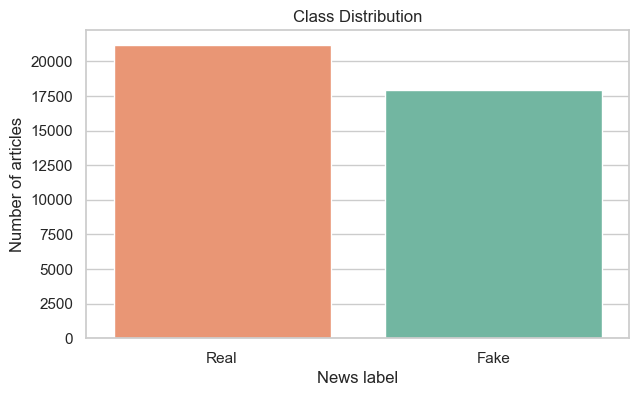

In [15]:
label_names = df['label'].map({0: 'Real', 1: 'Fake'})
plt.figure(figsize=(7, 4))
sns.countplot(x=label_names, order=['Real', 'Fake'], hue=label_names, palette='Set2', legend=False)
plt.title('Class Distribution')
plt.xlabel('News label')
plt.ylabel('Number of articles')
plt.show()

### Text length and word count distributions

Text length counts characters, while word count counts whitespace-separated words. These plots can reveal whether one class tends to contain unusually short or long documents.

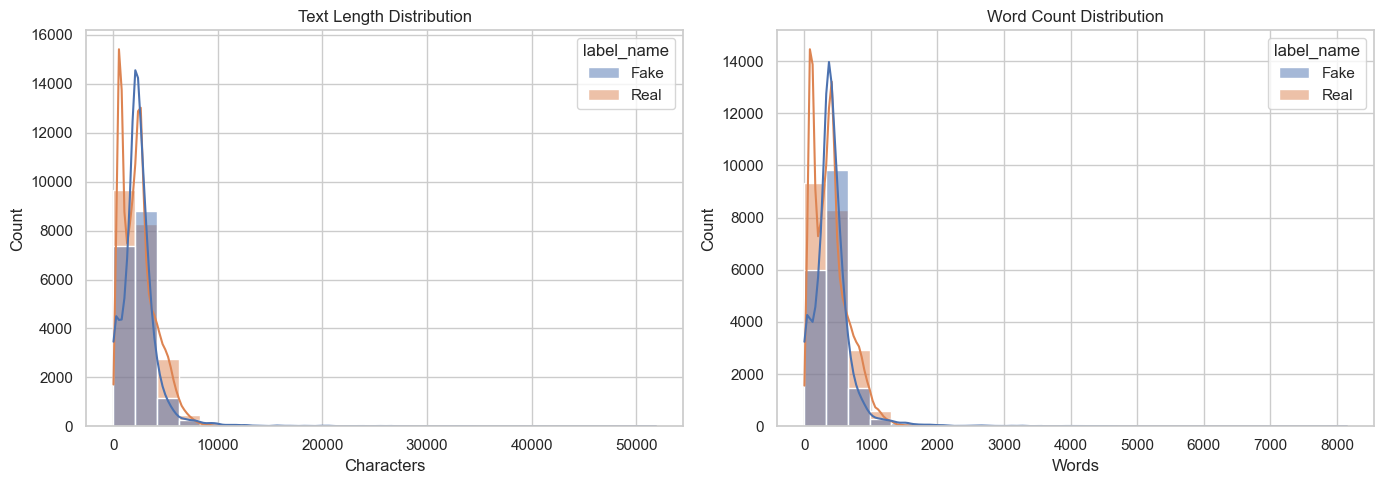

In [16]:
df['text_length'] = df['combined_text'].str.len()
df['word_count'] = df['combined_text'].str.split().str.len()
plot_df = df.assign(label_name=label_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=plot_df, x='text_length', hue='label_name', bins=25, kde=True, ax=axes[0])
axes[0].set_title('Text Length Distribution')
axes[0].set_xlabel('Characters')

sns.histplot(data=plot_df, x='word_count', hue='label_name', bins=25, kde=True, ax=axes[1])
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words')
plt.tight_layout()
plt.show()

## 4. Text preprocessing

Machine Learning models need consistent text. The clean_text function converts text to lowercase, removes URLs, HTML tags, numbers and punctuation, removes English stopwords, lemmatizes words, and returns normalized spacing. The same function is copied into app.py so training and prediction use identical cleaning rules.

In [17]:
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text):
    """Clean one title/article string for TF-IDF modelling."""
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    cleaned_tokens = [
        LEMMATIZER.lemmatize(word)
        for word in tokens
        if word not in STOP_WORDS and word.isalpha()
    ]
    return ' '.join(cleaned_tokens)

df['clean_text'] = df['combined_text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
display(df[['combined_text', 'clean_text', 'label']].head())

,combined_text,clean_text,label
0,BREAKING: GOP Chairman Grassley Has Had Enough...,breaking gop chairman grassley enough demand t...,1
1,Failed GOP Candidates Remembered In Hilarious ...,failed gop candidate remembered hilarious mock...,1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY ...,mike new dc neighbor hilariously trolling homo...,1
3,California AG pledges to defend birth control ...,california ag pledge defend birth control insu...,0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,az rancher living usmexico border destroy nanc...,1


## 5. Word clouds and top frequent words

Word clouds give a quick visual impression of words that appear frequently in each class. The frequency table gives an exact, more useful view of the 20 most common cleaned words in the entire dataset.

,word,frequency
0,said,120858
1,trump,117142
2,u,59976
3,state,51277
4,would,49620
5,president,46330
6,republican,37433
7,people,35672
8,one,31311
9,year,29858


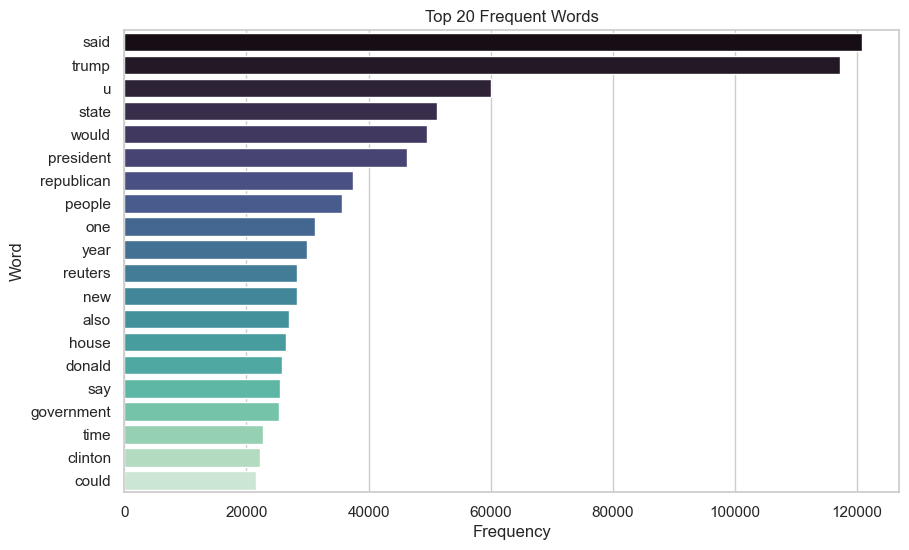

In [22]:
top_words = Counter(' '.join(df['clean_text']).split()).most_common(20)
top_words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])
display(top_words_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, x='frequency', y='word', hue='word', palette='mako', legend=False)
plt.title('Top 20 Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

## 6. Train-test split and TF-IDF feature engineering

We reserve 20% of the data for testing and preserve the class ratio with stratification. The TF-IDF vectorizer learns only from training text, avoiding information leakage from the test set. It uses up to 5,000 unigram and bigram features.

In [23]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df['label'],
)

tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)

print(f'Training feature matrix shape: {X_train.shape}')
print(f'Test feature matrix shape: {X_test.shape}')

Training feature matrix shape: (31278, 5000)
Test feature matrix shape: (7820, 5000)


## 7. Train and compare models

Three traditional classifiers are trained on exactly the same TF-IDF features. For each model, we calculate accuracy, precision, recall, and F1-score. F1-score for class 1 (fake) is used to select the best model because it balances precision and recall.

In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(random_state=RANDOM_STATE),
}

results = []
trained_models = {}
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    trained_models[model_name] = model
    predictions[model_name] = y_pred
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False).reset_index(drop=True)
print(results_df)

                     Model  Accuracy  Precision    Recall  F1-score
0               Linear SVM  0.993734   0.995511  0.990785  0.993142
1      Logistic Regression  0.987852   0.992095  0.981290  0.986663
2  Multinomial Naive Bayes  0.947698   0.941537  0.944429  0.942981


### Classification reports and confusion matrices

The classification report shows precision, recall, and F1-score for both labels. A confusion matrix makes correct and incorrect predictions easy to inspect.


Logistic Regression Classification Report
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4239
        Fake       0.99      0.98      0.99      3581

    accuracy                           0.99      7820
   macro avg       0.99      0.99      0.99      7820
weighted avg       0.99      0.99      0.99      7820


Multinomial Naive Bayes Classification Report
              precision    recall  f1-score   support

        Real       0.95      0.95      0.95      4239
        Fake       0.94      0.94      0.94      3581

    accuracy                           0.95      7820
   macro avg       0.95      0.95      0.95      7820
weighted avg       0.95      0.95      0.95      7820


Linear SVM Classification Report
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      4239
        Fake       1.00      0.99      0.99      3581

    accuracy                           0.99      7820
   m

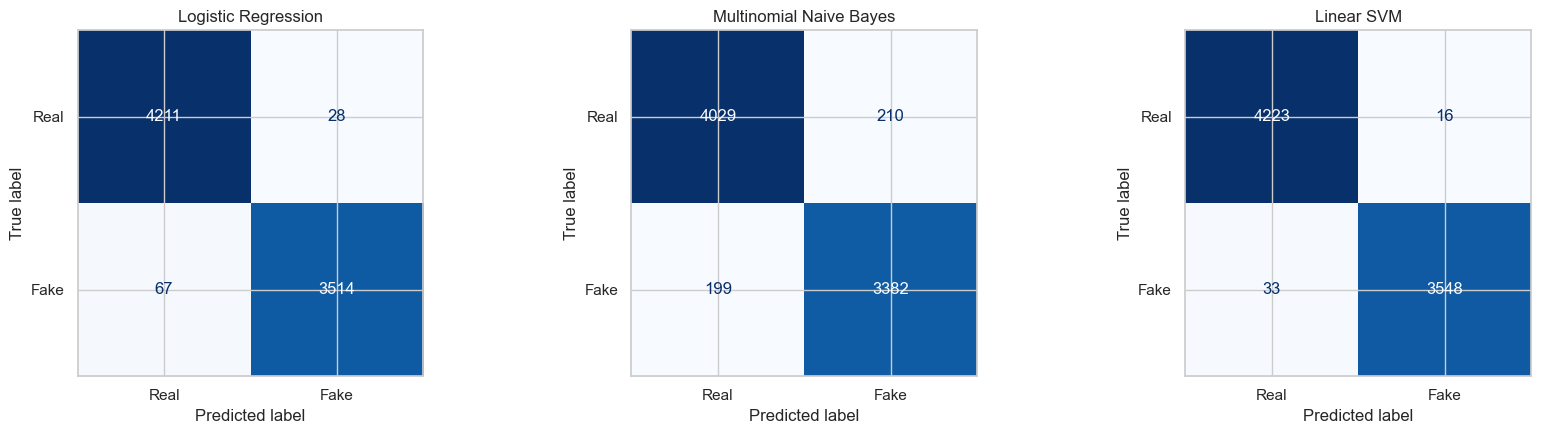

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for axis, (model_name, y_pred) in zip(axes, predictions.items()):
    print(f'\n{model_name} Classification Report')
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake'], zero_division=0))
    matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=['Real', 'Fake']).plot(
        ax=axis,
        colorbar=False,
        cmap='Blues',
    )
    axis.set_title(model_name)

plt.tight_layout()
plt.show()

## 8. Save the best model and vectorizer

The model with the highest fake-news F1-score is selected. Both the selected model and the fitted vectorizer are saved in the project root so that app.py can make predictions with the exact same feature mapping.

In [27]:
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]

joblib.dump(best_model, 'model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

print(f'Best model: {best_model_name}')
print(f'Best fake-news F1-score: {results_df.loc[0, "F1-score"]:.3f}')
print('Saved model.pkl and tfidf_vectorizer.pkl')

Best model: Linear SVM
Best fake-news F1-score: 0.993
Saved model.pkl and tfidf_vectorizer.pkl


## 9. Let's try one sample prediction

This final example uses the saved best model in memory.

In [29]:
sample_title = 'Council publishes official public transport update'
sample_text = 'The city transport department released its timetable on the official website.'
sample_clean_text = clean_text(f'{sample_title} {sample_text}')
sample_features = tfidf_vectorizer.transform([sample_clean_text])
sample_prediction = int(best_model.predict(sample_features)[0])
sample_label = 'FAKE' if sample_prediction == 1 else 'REAL'
print(f'Sample prediction: {sample_label}')

if hasattr(best_model, 'predict_proba'):
    confidence = max(best_model.predict_proba(sample_features)[0]) * 100
    print(f'Confidence score: {confidence:.2f}%')
else:
    print('Confidence score: unavailable for Linear SVM.')

Sample prediction: FAKE
Confidence score: unavailable for Linear SVM.
